In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
from functions import *
from pathlib import Path
home = str(Path.home())

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
tp = 'LPV'
id_ = '046499'
direc = home+'/Research_data/Bulge_Variables/%s/'%tp
direc_list = np.sort(glob(direc+'*.fits'))
list_periods = np.genfromtxt(home+'/Research_data/Bulge_Variables/%s/BLG_%s_OGLE_periods.txt'%(tp,tp)
                            , dtype='str')

In [3]:
name = '/Users/somayeh/Research_data/Bulge_Variables/%s/OGLE-BLG-%s-%s_multiband_lc.fits'%\
        (tp,tp, id_)

In [4]:
index = np.where(direc_list == name)[0][0] #0
path = direc_list[index]
ID = path.split('/')[-1].split('_')[0]
period = float(list_periods[list_periods[:, 0] == ID][0][1])

In [5]:
period, df = read_fits(path, 
                       period=period,
                       tp = tp)

In [6]:
print(df.groupby('band').size())
if np.isnan(period):
    pass
try:
    df = df[df.band=='I']
except AttributeError:
    pass

df = df.reset_index(drop=True)

if np.min(df.t)>0:
    df.t = df.t - np.min(df.t)

band
H0     1
I     71
dtype: int64


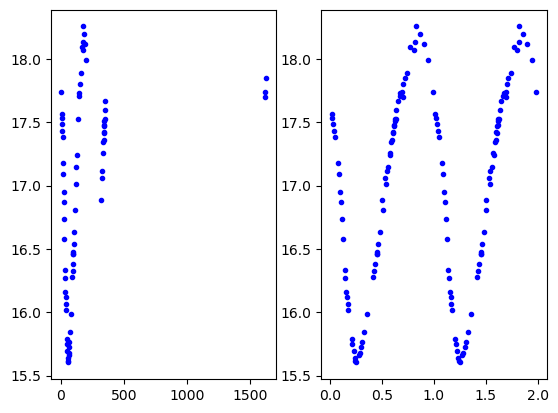

In [7]:
fig, axs = plt.subplots(1, 2)

axs[0].plot(df.t, df.m,'b.')
axs[1].plot(df.phase, df.m,'b.')
axs[1].plot(df.phase+1, df.m,'b.')

In [10]:
th = 100
t_diff = np.diff(df['t'].values)
t_diff = np.concatenate((t_diff, [1]), axis=0)

indxs = df[t_diff>th].index.values
df_gapped = df.copy(deep=True)

In [11]:
t_0_list = list(df.t[df.t<df.t[indxs[0]]])
m_0_list = list(df.m[df.t<df.t[indxs[0]]])

In [37]:
def get_phase(t, period):
    return (t/period)%1

def get_list_closest_phases(t_array, phs0, t0, period, offset_day=10):
    phase = (t_array/period)%1
    offset_phase = (offset_day/period)%1
    return t_array[np.abs(phase-phs0)<offset_phase]

In [38]:
p01 = get_phase(df.t[indxs[0]], period)

In [42]:
ind0 = get_list_closest_phases(df.t.values, p01,df.t[indxs[0]], period)

In [58]:
coeff = int((1713/period)-(1713/period)%1)

In [59]:
new_phase = []
new_t = []
new_m = []
new_e = []

In [61]:
for c in range(coeff):
    new_phase += list(((df.t.values/period)%1)+c)
    new_t += list(df.t.values+c*period)
    new_m += list(df.m.values)
    new_e += list(df.e.values)

In [62]:
new_df = pd.DataFrame({'phase':new_phase,
                       't': new_t,
                       'm': new_m,
                       'e': new_e})

In [66]:
new_df= new_df[new_df.t<1713]

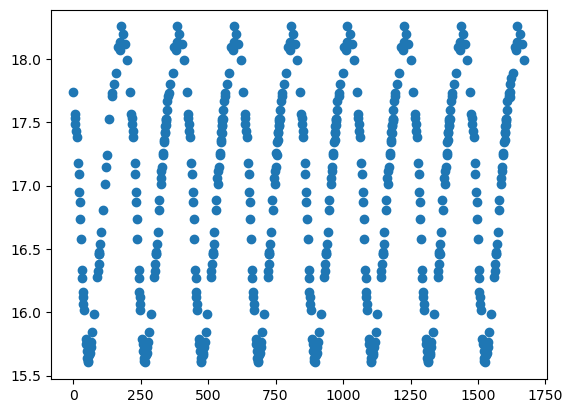

In [67]:
plt.scatter(new_df.t, new_df.m)

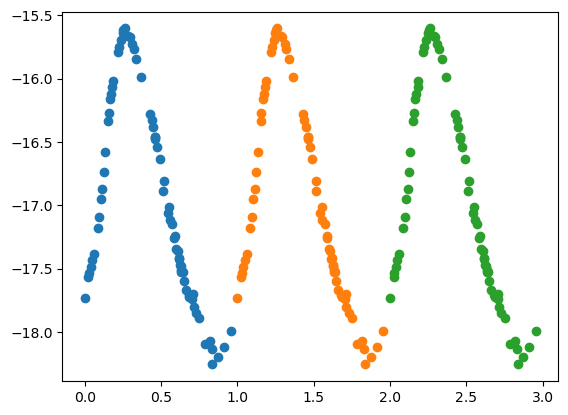

In [48]:
plt.scatter((df.t/period)%1, -1*df.m)
plt.scatter((df.t/period)%1+1, -1*df.m)
plt.scatter((df.t/period)%1+2, -1*df.m)

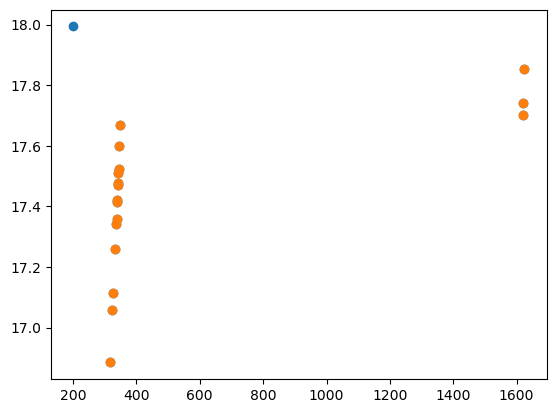

In [35]:
plt.scatter(df.t[df.t>df.t[ind0]], df.m[df.t>df.t[ind0]])
plt.scatter(df.t[df.t>df.t[indxs[0]]], df.m[df.t>df.t[indxs[0]]])

In [69]:
df_modified = new_df

In [13]:
if (np.max(df_modified.t))<1713 and np.isinf(info[tp]['n_phs']):
    df_modified = extend_baseline(df_modified, period)

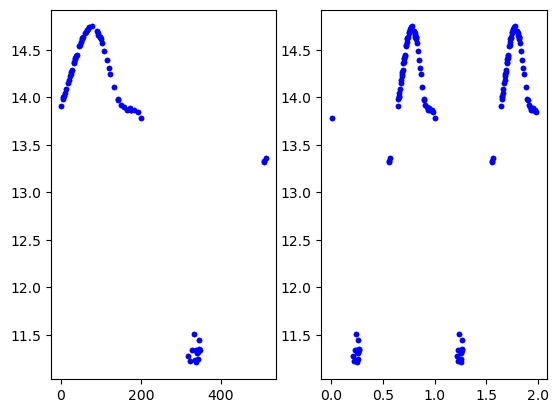

In [14]:
fig, axs = plt.subplots(1, 2)

axs[0].plot(df_modified.t, df_modified.m,'b.')
axs[1].plot(df_modified.phase, df_modified.m,'b.')
axs[1].plot(df_modified.phase+1, df_modified.m,'b.')

In [ ]:

# print(ID)






if (np.max(df.t))<1713:
    df = add_last_point(df, period)
df_modified = gap_reducer(df, period, info[tp], th=100, max_iters=50)
if (np.max(df_modified.t))<1713 and np.isinf(info[tp]['n_phs']):
    df_modified = extend_baseline(df_modified, period)
while np.max(df_modified.t.values)<1713+period:
    len_0 = np.diff(df_modified.t.values)
    df_modified = gap_reducer(df_modified, period, info[tp])
    len_1 = np.diff(df_modified.t.values)
    if np.max(df_modified.t.values)>1713:
        break
    if np.sum(len_0>50) == np.sum(len_1>50):
        break